In [1]:
import sys
sys.path.insert(0, '../../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [2]:
# ── LOAD ──────────────────────────────────────────────────────────────────────

TRIAL_WINDOW_SIZES   = [1, 2, 4, 8, 12, 16, 20, 24, 28, 32]        # in number of trials (~50s each)
TIME_WINDOW_SIZES_S  = [5, 10, 20, 30, 40]         # in seconds within a trial


# ── NH ────────────────────────────────────────────────────────────────────────

nh = {
    "envelope": {
        "trial": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_NH_trials_{n}_{s}_envelope.csv")
                for s in ("concatenate", "average")
            }
            for n in TRIAL_WINDOW_SIZES
        },

        "time": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_NH_time_{n}s_{s}_envelope.csv")
                for s in ("concatenate",)
            }
            for n in TIME_WINDOW_SIZES_S
        }
    },
    "envelope_onset": {
        "trial": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_NH_trials_{n}_{s}_envelope_onset.csv")
                for s in ("concatenate", "average")
            }
            for n in TRIAL_WINDOW_SIZES
        },

        "time": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_NH_time_{n}s_{s}_envelope_onset.csv")
                for s in ("concatenate",)
            }
            for n in TIME_WINDOW_SIZES_S
        }
    
    }
}

# ── HI ────────────────────────────────────────────────────────────────────────

hi = {
    "envelope" : {
        "trial": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_HI_trials_{n}_{s}_envelope.csv")
                for s in ("concatenate", "average")
            }
            for n in TRIAL_WINDOW_SIZES
        },

        "time": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_HI_time_{n}s_{s}_envelope.csv")
                for s in ("concatenate",)
            }
            for n in TIME_WINDOW_SIZES_S
        }
    },

    "envelope_onset": {
        "trial": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_HI_trials_{n}_{s}_envelope_onset.csv")
                for s in ("concatenate", "average")
            }
            for n in TRIAL_WINDOW_SIZES
        },

        "time": {
            n: {
                s: pd.read_csv(BEYOND_FUGLSANG_IN_SNHL_RESULTS / f"results_HI_time_{n}s_{s}_envelope_onset.csv")
                for s in ("concatenate",)
            }
            for n in TIME_WINDOW_SIZES_S
        }

    }
        
}

# convenience aliases for your existing 2×3 plot
results_nh       = nh["envelope"]["trial"][1]['concatenate']   # single trial, same as before
results_hi       = hi["envelope"]["trial"][1]['concatenate']
results_nh_cat   = nh["envelope"]["trial"][32]['concatenate']  # full subject concatenated
results_hi_cat   = hi["envelope"]["trial"][32]['concatenate']

results_nh.max()

subject             sub-044
group                    NH
window_size               1
window_dur_s             50
strategy        concatenate
attend_side     attendright
difficulty             99.0
score                 100.0
r_att              0.281446
r_ign               0.18108
delta_r            0.358439
correct                True
dtype: object

# Envelope plots

In [3]:
# Plotting function ------------------------------------------------------

def plot_scatter_panel(ax, df, color, title, groupby_subject=False, annotate=False, lim = [-0.4, 0.50]):

    if groupby_subject:
        agg       = df.groupby('subject')[['r_att', 'r_ign']].mean()
        r_att     = agg['r_att'].values
        r_ign     = agg['r_ign'].values
        labels    = [s.replace('sub-', '') for s in agg.index]
    else:
        r_att  = df['r_att'].values
        r_ign  = df['r_ign'].values
        labels = df['subject'].str.replace('sub-', '').values

    correct = r_att > r_ign
    acc     = correct.mean()

    ax.scatter(r_att[correct],  r_ign[correct],
               color=color, edgecolors='white', linewidths=0.5,
               s=15, zorder=3, marker='o', label=f'Correct ({acc:.0%})')
    ax.scatter(r_att[~correct], r_ign[~correct],
               color="red", edgecolors='red', linewidths=0.8,
               s=15, zorder=3, marker='x', label=f'Incorrect ({1-acc:.0%})')

    if annotate:
        for s, x, y in zip(labels, r_att, r_ign):
            ax.annotate(s, (x, y),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=6.5, color=color, alpha=0.85)

    all_r = np.concatenate([r_att, r_ign])
    ax.plot(lim, lim, 'k--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$r_{att}$', fontsize=9)
    ax.set_ylabel(r'$r_{ign}$', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84027/2692655850.py:21: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_att[~correct], r_ign[~correct],


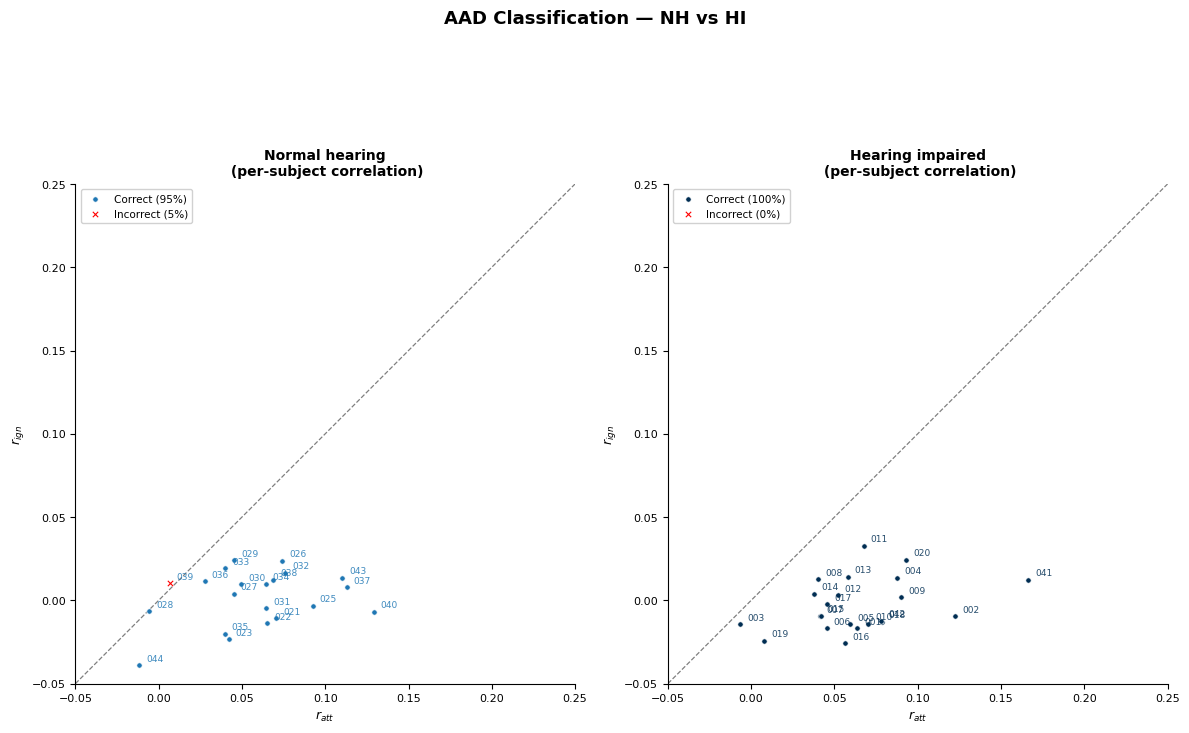

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8.5))
ax_nh = axes[0]
ax_hi = axes[1]
plot_scatter_panel(
    ax_nh, results_nh_cat,
    color='tab:blue',
    title='Normal hearing\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.05,0.25]
)
plot_scatter_panel(
    ax_hi, results_hi_cat,
    color='#002D52',
    title='Hearing impaired\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.05,0.25]
)
fig.suptitle('AAD Classification — NH vs HI', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(BEYOND_FIGURES_DIR / 'aad_subject_scatter_nh_hi.png', dpi=170, bbox_inches='tight')
plt.show()

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84027/2692655850.py:21: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_att[~correct], r_ign[~correct],


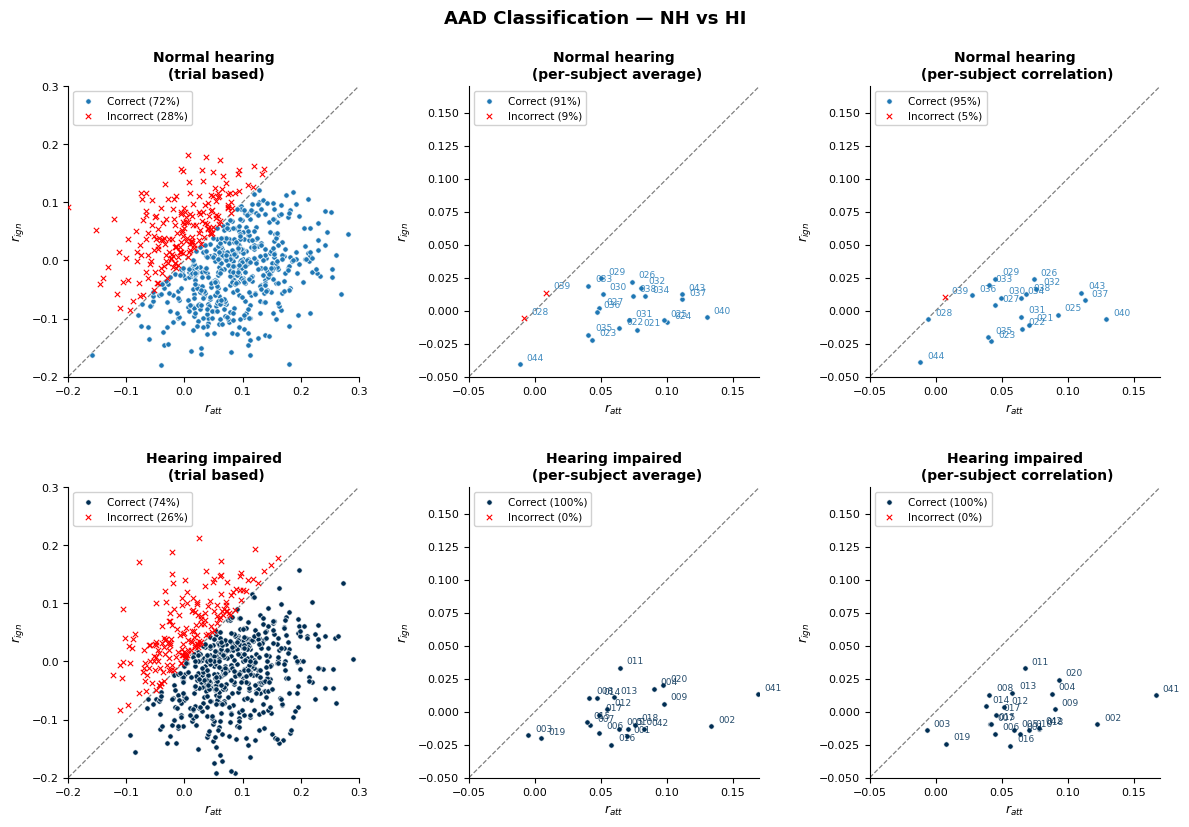

In [29]:
# ALL AAD APPROACHES --------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 8.5))
ax_nh1, ax_nh2, ax_nh3 = axes[0]
ax_hi1, ax_hi2, ax_hi3 = axes[1]

plot_scatter_panel(
    ax_nh1, results_nh,
    color='tab:blue',
    title='Normal hearing\n (trial based)',
    groupby_subject=False,
    lim=[-0.2,0.3]
)
plot_scatter_panel(
    ax_nh2, results_nh,
    color='tab:blue',
    title='Normal hearing\n (per-subject average)',
    groupby_subject=True,
    annotate=True,
    lim=[-0.05,0.17]
)
plot_scatter_panel(
    ax_nh3, results_nh_cat,
    color='tab:blue',
    title='Normal hearing\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.05,0.17]
)


plot_scatter_panel(
    ax_hi1, results_hi,
    color='#002D52',
    title='Hearing impaired\n (trial based)',
    groupby_subject=False,
    lim=[-0.2,0.3]
)
plot_scatter_panel(
    ax_hi2, results_hi,
    color='#002D52',
    title='Hearing impaired\n (per-subject average)',
    groupby_subject=True,
    annotate=True,
    lim=[-0.05,0.17]
)
plot_scatter_panel(
    ax_hi3, results_hi_cat,
    color='#002D52',
    title='Hearing impaired\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.05,0.17]
)


fig.suptitle('AAD Classification — NH vs HI', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(BEYOND_FIGURES_DIR / 'aad_scatter_nh_hi.png', dpi=170, bbox_inches='tight')
plt.show()

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84027/2692655850.py:21: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_att[~correct], r_ign[~correct],


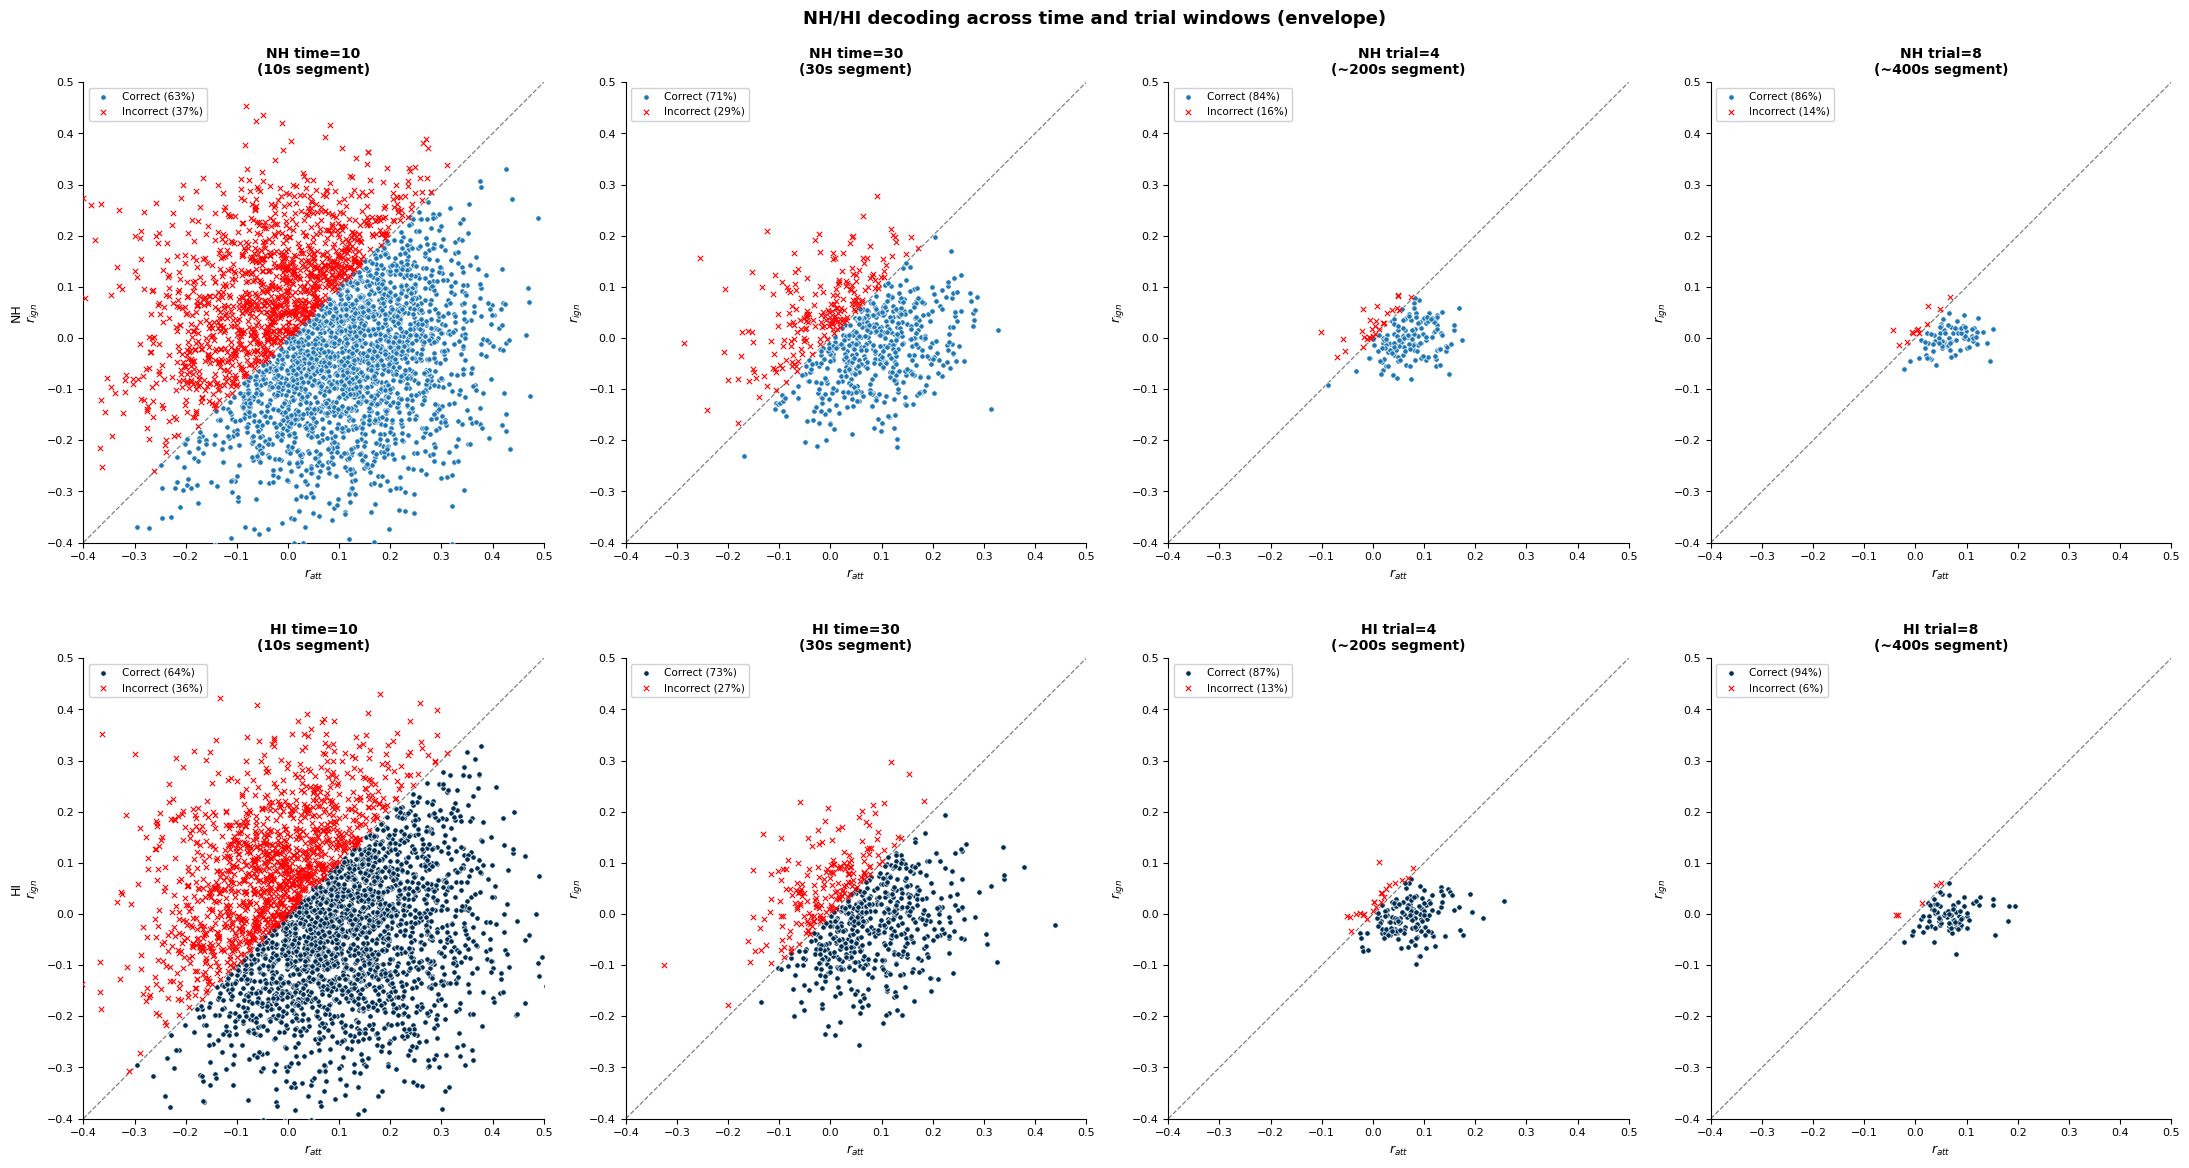

In [24]:
 # ── PLOT: time + trial windows ───────────────────────────────────────────────

all_windows = (
    [('envelope', 'time', n)  for n in [10, 30]] +
    [('envelope', 'trial', n) for n in [4, 8]]
)

fig, axes = plt.subplots(2, len(all_windows), figsize=(22, 12))

for col, (preprefix, prefix, n) in enumerate(all_windows):

    # label formatting
    if prefix == 'time':
        title = f'{n}s segment'
    else:
        title = f'~{n*50}s segment'

    # NH
    plot_scatter_panel(
        axes[0, col],
        nh[preprefix][prefix][n]['concatenate'],
        color='tab:blue',
        title=f'NH {prefix}={n}\n({title})'
    )

    # HI
    plot_scatter_panel(
        axes[1, col],
        hi[preprefix][prefix][n]['concatenate'],
        color="#002D52",
        title=f'HI {prefix}={n}\n({title})'
    )

axes[0, 0].set_ylabel('NH\n$r_{ign}$', fontsize=9)
axes[1, 0].set_ylabel('HI\n$r_{ign}$', fontsize=9)

fig.suptitle(
    'NH/HI decoding across time and trial windows (envelope)',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()

fig.savefig(
    BEYOND_FIGURES_DIR / 'aad_scatter_nh_hi_windows.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()

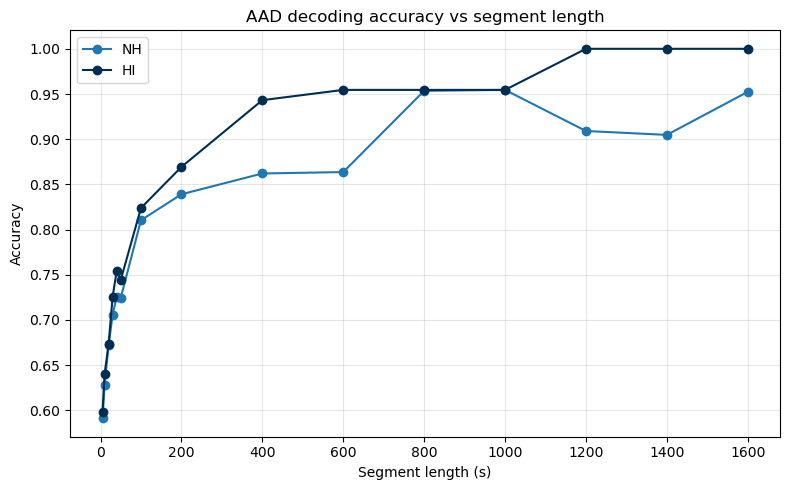

In [30]:
# ── ACCURACY VS SEGMENT LENGTH ───────────────────────────────────────────────

all_windows = (
    [("envelope", 'time', n)  for n in TIME_WINDOW_SIZES_S] +
    [("envelope", 'trial', n) for n in TRIAL_WINDOW_SIZES]
)

nh_acc = []
hi_acc = []
segment_times = []

for preprefix, prefix, n in all_windows:

    # convert everything to seconds
    if prefix == 'time':
        segment_time = n
    else:
        segment_time = n * 50   # ~50s per trial

    segment_times.append(segment_time)

    # accuracy = mean(correct)
    nh_accuracy = nh[preprefix][prefix][n]['concatenate']['correct'].mean()
    hi_accuracy = hi[preprefix][prefix][n]['concatenate']['correct'].mean()

    nh_acc.append(nh_accuracy)
    hi_acc.append(hi_accuracy)


# ── PLOT ──────────────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))

plt.plot(segment_times, nh_acc, marker='o', label='NH', color='tab:blue')
plt.plot(segment_times, hi_acc, marker='o', label='HI', color='#002D52')

plt.xlabel('Segment length (s)')
plt.ylabel('Accuracy')

plt.title('AAD decoding accuracy vs segment length')

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    BEYOND_FIGURES_DIR / 'aad_accuracy_vs_segment_length.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()

## Subject trials concatenation vs averaging

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84027/2692655850.py:21: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_att[~correct], r_ign[~correct],


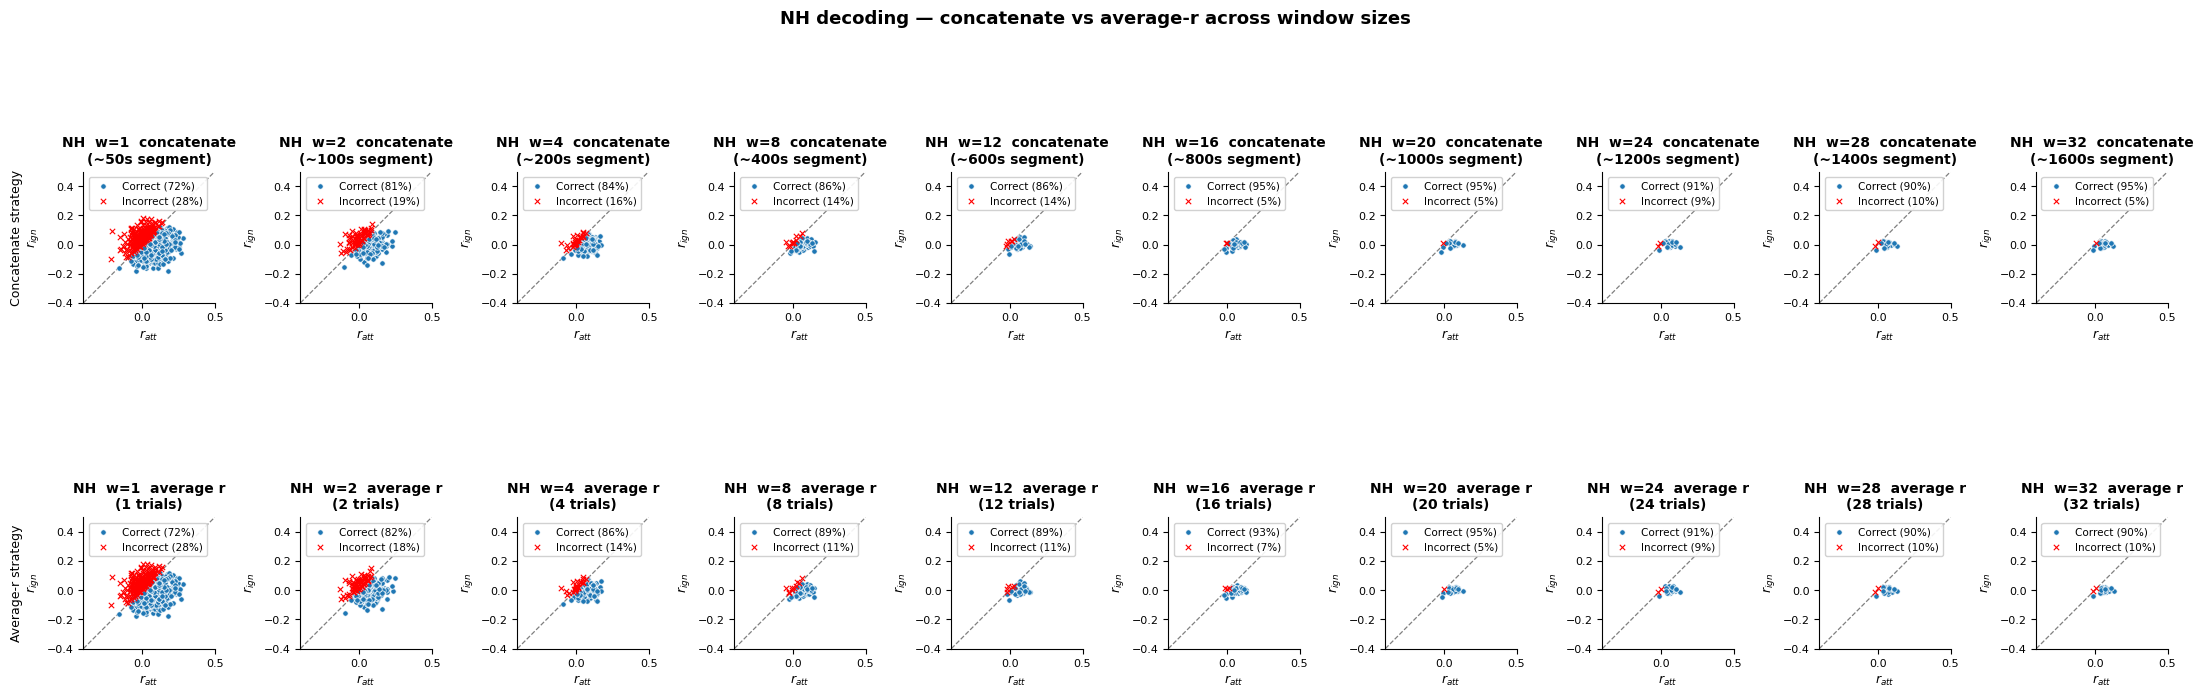

In [8]:
# ── PLOT: window size × strategy (NH) ─────────────────────────────────────────

fig, axes = plt.subplots(2, len(TRIAL_WINDOW_SIZES), figsize=(22, 8))

for col, n in enumerate(TRIAL_WINDOW_SIZES):
    plot_scatter_panel(axes[0, col], nh["envelope"]["trial"][n]['concatenate'],
                       color='tab:blue',
                       title=f'NH  w={n}  concatenate\n(~{n*50}s segment)')
    plot_scatter_panel(axes[1, col], nh["envelope"]["trial"][n]['average'],
                       color='tab:blue',
                       title=f'NH  w={n}  average r\n({n} trials)')

axes[0, 0].set_ylabel('Concatenate strategy\n$r_{ign}$', fontsize=9)
axes[1, 0].set_ylabel('Average-r strategy\n$r_{ign}$',   fontsize=9)

fig.suptitle('NH decoding — concatenate vs average-r across window sizes',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(BEYOND_FIGURES_DIR / 'aad_scatter_nh_strategies.png', dpi=170, bbox_inches='tight')
plt.show()

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84027/2692655850.py:21: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_att[~correct], r_ign[~correct],


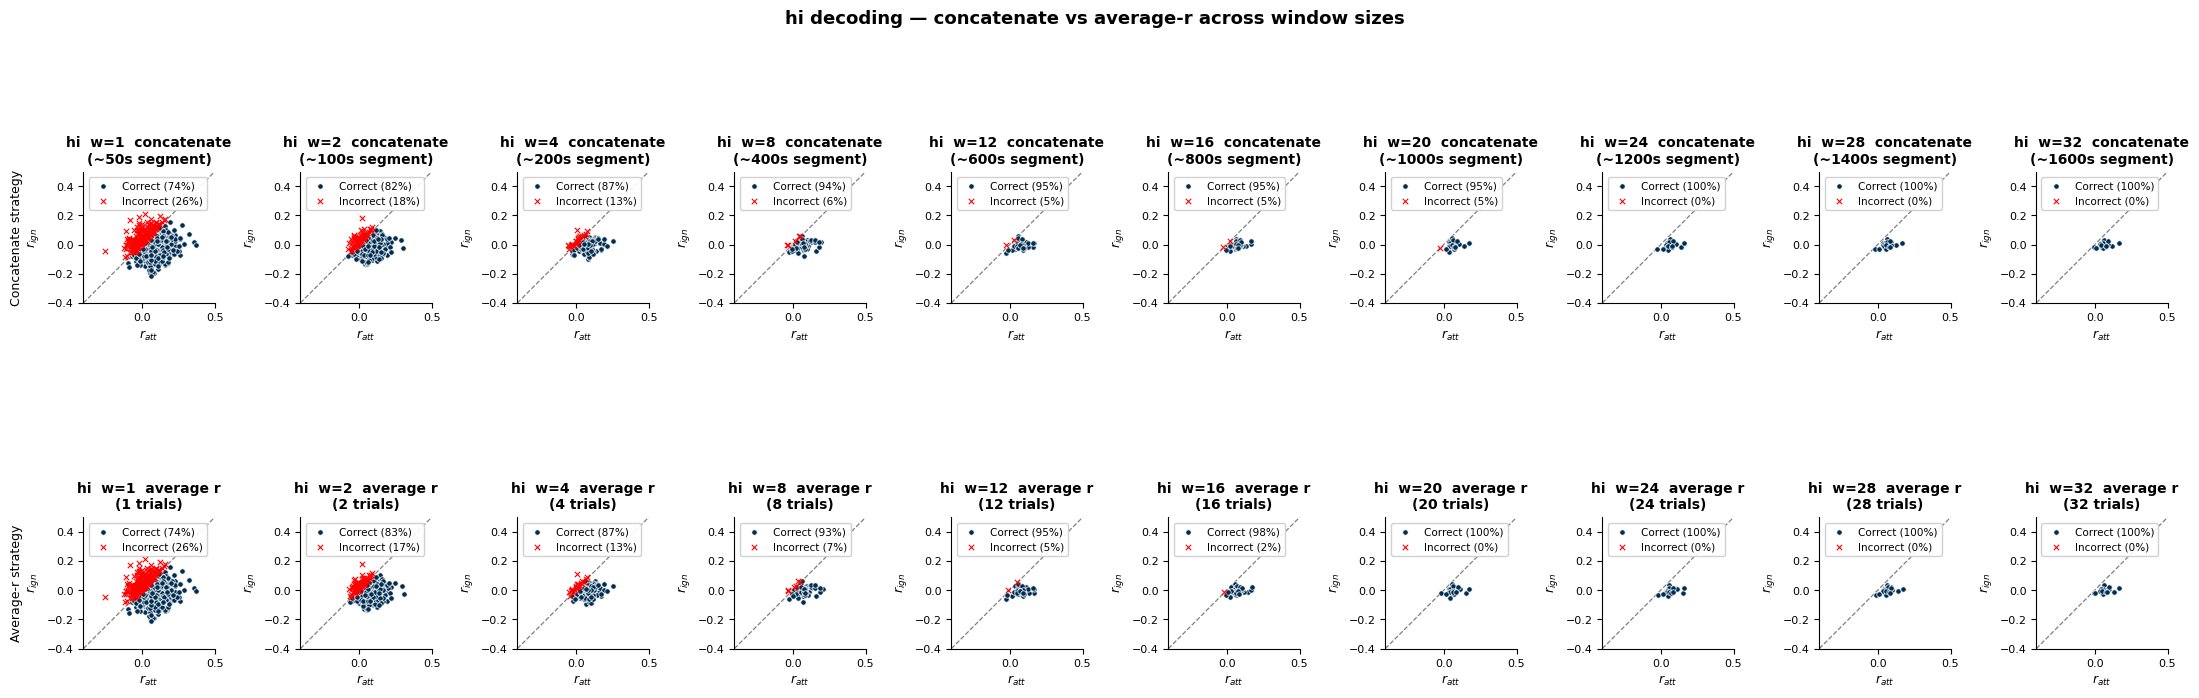

In [31]:
# ── PLOT: window size × strategy (hi) ─────────────────────────────────────────

fig, axes = plt.subplots(2, len(TRIAL_WINDOW_SIZES), figsize=(22, 8))

for col, n in enumerate(TRIAL_WINDOW_SIZES):
    plot_scatter_panel(axes[0, col], hi["envelope"]["trial"][n]['concatenate'],
                       color='#002D52',
                       title=f'hi  w={n}  concatenate\n(~{n*50}s segment)')
    plot_scatter_panel(axes[1, col], hi["envelope"]["trial"][n]['average'],
                       color='#002D52',
                       title=f'hi  w={n}  average r\n({n} trials)')

axes[0, 0].set_ylabel('Concatenate strategy\n$r_{ign}$', fontsize=9)
axes[1, 0].set_ylabel('Average-r strategy\n$r_{ign}$',   fontsize=9)

fig.suptitle('hi decoding — concatenate vs average-r across window sizes',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(BEYOND_FIGURES_DIR / 'aad_scatter_nh_strategies.png', dpi=170, bbox_inches='tight')
plt.show()

# Envelope Onset plots

/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84027/2692655850.py:21: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r_att[~correct], r_ign[~correct],


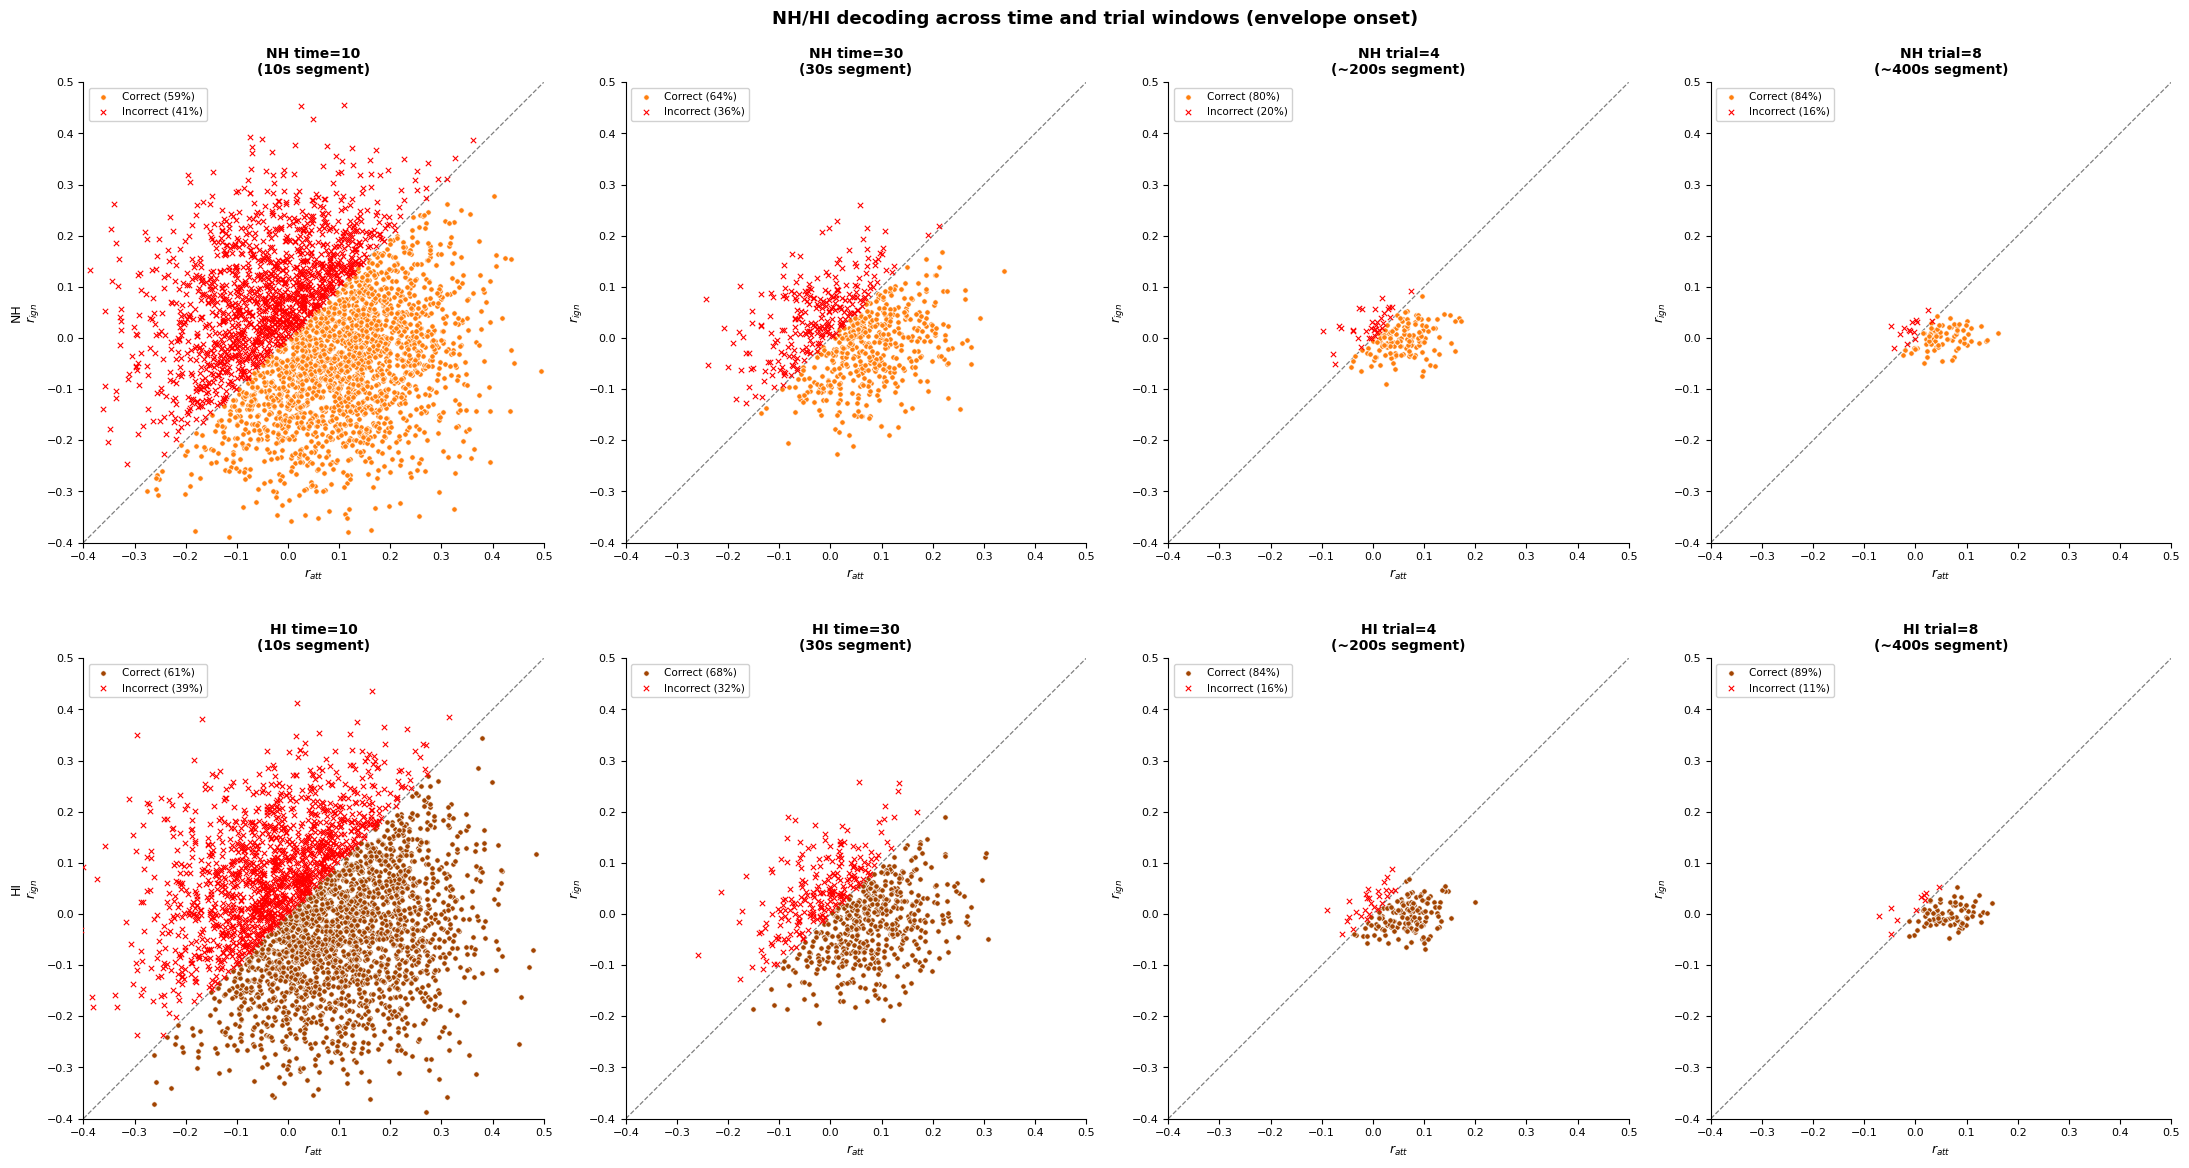

In [20]:
 # ── PLOT: time + trial windows ───────────────────────────────────────────────

all_windows = (
    [('envelope_onset', 'time', n)  for n in [10, 30]] +
    [('envelope_onset', 'trial', n) for n in [4, 8]]
)

fig, axes = plt.subplots(2, len(all_windows), figsize=(22, 12))

for col, (preprefix, prefix, n) in enumerate(all_windows):

    # label formatting
    if prefix == 'time':
        title = f'{n}s segment'
    else:
        title = f'~{n*50}s segment'

    # NH
    plot_scatter_panel(
        axes[0, col],
        nh[preprefix][prefix][n]['concatenate'],
        color='tab:orange',
        title=f'NH {prefix}={n}\n({title})'
    )

    # HI
    plot_scatter_panel(
        axes[1, col],
        hi[preprefix][prefix][n]['concatenate'],
        color="#A24401",
        title=f'HI {prefix}={n}\n({title})'
    )

axes[0, 0].set_ylabel('NH\n$r_{ign}$', fontsize=9)
axes[1, 0].set_ylabel('HI\n$r_{ign}$', fontsize=9)

fig.suptitle(
    'NH/HI decoding across time and trial windows (envelope onset)',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()

fig.savefig(
    BEYOND_FIGURES_DIR / 'aad_scatter_nh_hi_windows.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()

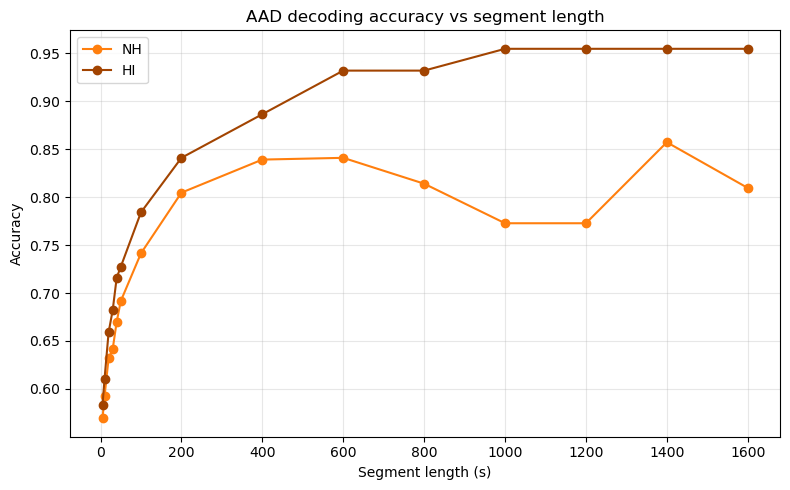

In [25]:
# ── ACCURACY VS SEGMENT LENGTH ───────────────────────────────────────────────

all_windows = (
    [("envelope_onset", 'time', n)  for n in TIME_WINDOW_SIZES_S] +
    [("envelope_onset", 'trial', n) for n in TRIAL_WINDOW_SIZES]
)

nh_acc = []
hi_acc = []
segment_times = []

for preprefix, prefix, n in all_windows:

    # convert everything to seconds
    if prefix == 'time':
        segment_time = n
    else:
        segment_time = n * 50   # ~50s per trial

    segment_times.append(segment_time)

    # accuracy = mean(correct)
    nh_accuracy = nh[preprefix][prefix][n]['concatenate']['correct'].mean()
    hi_accuracy = hi[preprefix][prefix][n]['concatenate']['correct'].mean()

    nh_acc.append(nh_accuracy)
    hi_acc.append(hi_accuracy)


# ── PLOT ──────────────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))

plt.plot(segment_times, nh_acc, marker='o', label='NH', color='tab:orange')
plt.plot(segment_times, hi_acc, marker='o', label='HI', color="#A24401")

plt.xlabel('Segment length (s)')
plt.ylabel('Accuracy')

plt.title('AAD decoding accuracy vs segment length')

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    BEYOND_FIGURES_DIR / 'aad_accuracy_vs_segment_length.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()